# 12-Production Model Serving Topologies (FastAPI & Docker)

In Lesson 11, we built an automated Continuous Integration (CI) pipeline to mathematically guarantee that our source code is free of syntax errors and logical flaws before it merges. Our code is secure, our MLflow artifacts are tracked, and our multi-stage Dockerfiles are optimized.

Now, we must bridge the gap between a static model weight file (`.pkl` or `.pt`) and a live, high-velocity application. A model resting on a hard drive generates zero business value. It must be wrapped in a **Serving Engine** exposed via an HTTP REST API.

Historically, Python developers used synchronous frameworks like Flask or Django. However, in an AI context where a deep learning forward pass might take 200 milliseconds, synchronous frameworks block the execution thread, queuing up requests and triggering catastrophic latency spikes under load.

To engineer Enterprise-grade serving topologies, we utilize **FastAPI** running on an **ASGI (Asynchronous Server Gateway Interface)** engine like Uvicorn. We will wrap this asynchronous application in an immutable Docker container, achieving extreme high-throughput serving for absolute $0.00 infrastructure cost.

# 1. The Mathematics of Asynchronous I/O & Concurrency

### WSGI (Synchronous Thread Blocking)

In a traditional WSGI server (like Flask/Gunicorn), a single network request locks an entire operating system thread for the full duration of the transaction.
Let $T_{total}$ be the time to process an inference request:


$$T_{total} = T_{network\_io} + T_{compute}$$

If $T_{network\_io} = 100\text{ms}$ and $T_{compute} = 50\text{ms}$, the thread is locked for $150\text{ms}$. If you have exactly 4 worker threads, your server can only handle 4 concurrent users. The 5th user is mathematically forced to wait in the TCP backlog queue, experiencing severe latency.

### ASGI (The Asynchronous Event Loop)

FastAPI utilizes the `asyncio` event loop. Concurrency is not Parallelism. Instead of locking a thread during network wait times, the thread **yields** control back to the event loop the microsecond it hits an I/O boundary (like downloading an image or waiting for a database).

Let $\mathcal{E}$ be the single Event Loop thread. When Request $A$ hits $T_{network\_io}$, $\mathcal{E}$ instantly context-switches to process the compute phase of Request $B$.


$$\text{Throughput} (\lambda) \propto \frac{1}{T_{compute}}$$


The server's theoretical maximum throughput is no longer bounded by $T_{network\_io}$. By offloading the pure CPU-bound mathematical operations (the model's forward pass) to a separate `ThreadPoolExecutor`, a single Uvicorn process can manage tens of thousands of concurrent TCP connections simultaneously.

### Pydantic & Type Theory

FastAPI enforces strict input validation using **Pydantic**. We define our input schema as a strict mathematical set $\mathbb{S}$. If a client transmits a JSON payload $x$, the serving engine evaluates $x \in \mathbb{S}$ before a single line of Python logic executes. If $x \notin \mathbb{S}$, the API instantly drops the payload and returns an HTTP 422 Unprocessable Entity error, protecting the model from catastrophic tensor shape mismatches.

# 2. Imperative Execution: Engineering the FastAPI Engine

Let's use Python to programmatically construct our production API. We will define strict mathematical data schemas, load a mock MLflow model, and instantiate the asynchronous routing topology.

In [1]:
import os

print("--- 🚀 Initializing FastAPI Serving Topology Lab ---")

serving_sandbox = "./serving_sandbox"
os.makedirs(serving_sandbox, exist_ok=True)

# 1. 📝 Write the FastAPI Application Code (main.py)
fastapi_code = """
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import time
import asyncio

# 1. Instantiate the ASGI Application Topology
app = FastAPI(title="Enterprise Inference Engine", version="1.0")

# 2. Define the Strict Mathematical Schema Boundary (Pydantic)
class InferenceRequest(BaseModel):
    # Field enforces strict boundary conditions on the input vectors
    feature_1: float = Field(..., description="Normalized scalar input", ge=-1.0, le=1.0)
    feature_2: int = Field(..., description="Categorical token ID", ge=0)
    
class InferenceResponse(BaseModel):
    prediction: float
    latency_ms: float
    model_version: str

# 3. Simulate a globally loaded Model Weight Matrix
MOCK_MODEL_WEIGHT = 0.85

@app.on_event("startup")
async def load_model_weights():
    # In production, this pulls the artifact from MLflow or S3 into memory ONCE at boot
    print("[SYSTEM] Loading Neural Network weights into memory...")
    await asyncio.sleep(1) # Simulating I/O delay
    print("[SYSTEM] Model successfully mounted to VRAM.")

# 4. Define the Asynchronous POST Endpoint
@app.post("/predict", response_model=InferenceResponse)
async def predict(payload: InferenceRequest):
    start_time = time.perf_counter()
    
    try:
        # Simulate CPU-bound mathematical forward pass
        # feature_1 * weight + feature_2 bias
        raw_prediction = (payload.feature_1 * MOCK_MODEL_WEIGHT) + (payload.feature_2 * 0.1)
        
        # Calculate execution latency
        exec_time = (time.perf_counter() - start_time) * 1000
        
        return InferenceResponse(
            prediction=round(raw_prediction, 4),
            latency_ms=round(exec_time, 2),
            model_version="v1.0.4-xgboost"
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail="Inference Matrix Failure")

@app.get("/health")
async def health_check():
    return {"status": "healthy", "engine": "FastAPI ASGI"}
"""

main_py_path = os.path.join(serving_sandbox, "main.py")
with open(main_py_path, "w") as f:
    f.write(fastapi_code.strip())

print(f"   ✅ FastAPI Serving Code Compiled: {main_py_path}")

--- 🚀 Initializing FastAPI Serving Topology Lab ---
   ✅ FastAPI Serving Code Compiled: ./serving_sandbox/main.py


# 3. Declarative Execution: The Production Container (Uvicorn)

We cannot run `python main.py` in production. We must wrap this API inside a mathematically optimized Docker container using a multi-worker ASGI server layout (Uvicorn managed by Gunicorn, or Uvicorn with multiple `--workers`).

Let's generate the deployment architecture.

In [2]:
# 2. 🐳 Write the Production Dockerfile
dockerfile_code = """
# STAGE 1: The Builder (Compiling dependencies)
FROM python:3.10-slim AS builder
WORKDIR /app
RUN pip install --user fastapi uvicorn pydantic

# STAGE 2: The Minimal Runtime
FROM python:3.10-slim AS runtime
WORKDIR /app

# Secure execution by dropping root privileges
RUN useradd -m api_user
USER api_user

# Copy dependencies and source code
COPY --from=builder /root/.local /home/api_user/.local
ENV PATH=/home/api_user/.local/bin:$PATH
COPY main.py .

# EXPOSE documentation port
EXPOSE 8000

# KERNEL COMMAND: Boot Uvicorn ASGI engine with 4 parallel worker processes
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000", "--workers", "4"]
"""

dockerfile_path = os.path.join(serving_sandbox, "Dockerfile")
with open(dockerfile_path, "w") as f:
    f.write(dockerfile_code.strip())

print(f"   ✅ Production Dockerfile Compiled: {dockerfile_path}")

print("\n--- ⚡ Deployment & Interaction Instructions ---")
print("To boot this high-throughput inference engine locally for $0.00, execute:")
print(f"   1. Build the Immutable Layer:  cd {serving_sandbox} && docker build -t enterprise-api:v1 .")
print(f"   2. Boot the Container:         docker run -d -p 8000:8000 enterprise-api:v1")
print(f"\n   -> View automatic Swagger API Docs: http://127.0.0.1:8000/docs")
print(f"   -> Execute a curl test payload:")
print(f"      curl -X 'POST' 'http://127.0.0.1:8000/predict' -H 'Content-Type: application/json' -d '{{\"feature_1\": 0.5, \"feature_2\": 3}}'")

   ✅ Production Dockerfile Compiled: ./serving_sandbox/Dockerfile

--- ⚡ Deployment & Interaction Instructions ---
To boot this high-throughput inference engine locally for $0.00, execute:
   1. Build the Immutable Layer:  cd ./serving_sandbox && docker build -t enterprise-api:v1 .
   2. Boot the Container:         docker run -d -p 8000:8000 enterprise-api:v1

   -> View automatic Swagger API Docs: http://127.0.0.1:8000/docs
   -> Execute a curl test payload:
      curl -X 'POST' 'http://127.0.0.1:8000/predict' -H 'Content-Type: application/json' -d '{"feature_1": 0.5, "feature_2": 3}'


# 4. Visualizing the Asynchronous Event Loop Topology

To fully grasp why FastAPI achieves massive throughput compared to legacy Python frameworks, let's graph the mathematical queuing theory behind the Asynchronous Event Loop.

/tmp/ipykernel_4578/848742085.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 0.5), 6.0, 7.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_4578/848742085.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.5, 2.0), 4.0, 2.5, fill=True, color='#f1c40f', alpha=0.2, edgecolor='black', linewidth=2))
/tmp/ipykernel_4578/848742085.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((2.0, 2.9), 3.0, 0.6, fill=True, color='#e74c3c', edgecolor='black'))
/tmp/ipykernel_4578/848742085.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((2.0, 2.2), 3.0, 0.6, fill=True, color='#e74c3c', edgecolor='bla

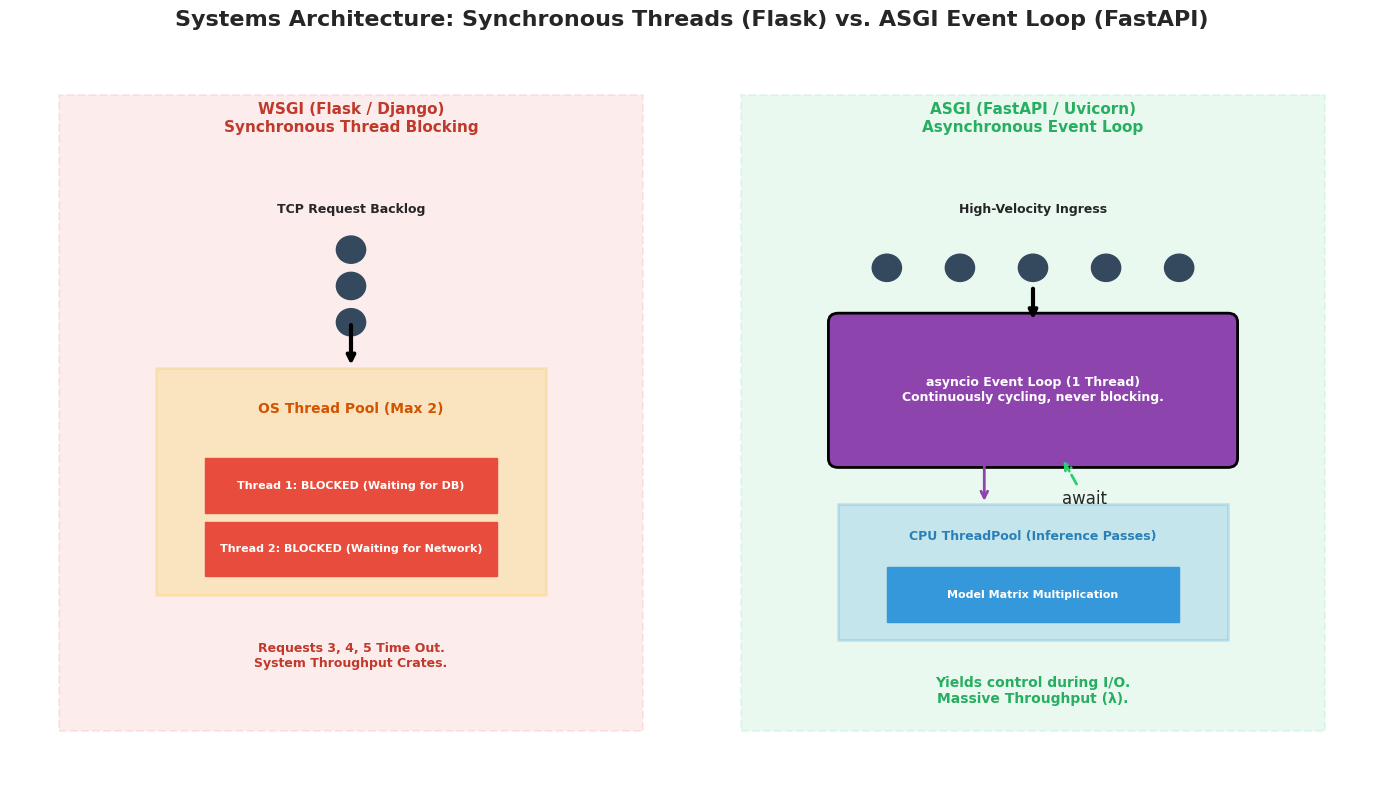

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for ASGI Event Loop Architecture
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: Synchronous Threads (Flask) vs. ASGI Event Loop (FastAPI)", fontsize=16, fontweight='bold')

ax.axis('off')

# ----------------------------------------------------
# LEFT: WSGI Synchronous (The Thread Bottleneck)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((0.5, 0.5), 6.0, 7.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(3.5, 7.1, "WSGI (Flask / Django)\nSynchronous Thread Blocking", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

# Request Queue
ax.text(3.5, 6.2, "TCP Request Backlog", ha='center', fontweight='bold', fontsize=9)
for i in range(3):
    ax.add_patch(patches.Circle((3.5, 5.8 - (i*0.4)), 0.15, fill=True, color='#34495e'))

# Worker Threads (Blocked)
ax.add_patch(patches.Rectangle((1.5, 2.0), 4.0, 2.5, fill=True, color='#f1c40f', alpha=0.2, edgecolor='black', linewidth=2))
ax.text(3.5, 4.0, "OS Thread Pool (Max 2)", ha='center', color='#d35400', fontweight='bold', fontsize=10)

ax.add_patch(patches.Rectangle((2.0, 2.9), 3.0, 0.6, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(3.5, 3.2, "Thread 1: BLOCKED (Waiting for DB)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

ax.add_patch(patches.Rectangle((2.0, 2.2), 3.0, 0.6, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(3.5, 2.5, "Thread 2: BLOCKED (Waiting for Network)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# The result: Queue builds up, system crashes
ax.annotate("", xy=(3.5, 4.5), xytext=(3.5, 5.0), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.text(3.5, 1.2, "Requests 3, 4, 5 Time Out.\nSystem Throughput Crates.", ha='center', color='#c0392b', fontweight='bold', fontsize=9)


# ----------------------------------------------------
# RIGHT: ASGI Asynchronous (The Event Loop)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((7.5, 0.5), 6.0, 7.0, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(10.5, 7.1, "ASGI (FastAPI / Uvicorn)\nAsynchronous Event Loop", ha='center', color='#27ae60', fontweight='bold', fontsize=11)

# Massive Request Queue handoff
ax.text(10.5, 6.2, "High-Velocity Ingress", ha='center', fontweight='bold', fontsize=9)
for i in range(5):
    ax.add_patch(patches.Circle((9.0 + (i*0.75), 5.6), 0.15, fill=True, color='#34495e'))

# The Event Loop Matrix
ax.add_patch(patches.FancyBboxPatch((8.5, 3.5), 4.0, 1.5, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#8e44ad'))
ax.text(10.5, 4.25, "asyncio Event Loop (1 Thread)\nContinuously cycling, never blocking.", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Delegated Compute Tasks
ax.add_patch(patches.Rectangle((8.5, 1.5), 4.0, 1.5, fill=True, color='#3498db', alpha=0.2, edgecolor='black', linewidth=2))
ax.text(10.5, 2.6, "CPU ThreadPool (Inference Passes)", ha='center', color='#2980b9', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((9.0, 1.7), 3.0, 0.6, fill=True, color='#3498db', edgecolor='black'))
ax.text(10.5, 2.0, "Model Matrix Multiplication", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# Connective Arrows showing yield physics
ax.annotate("", xy=(10.5, 5.0), xytext=(10.5, 5.4), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.annotate("", xy=(10.0, 3.0), xytext=(10.0, 3.5), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad"))
ax.annotate("await", xy=(10.8, 3.5), xytext=(10.8, 3.0), arrowprops=dict(arrowstyle="->", lw=2, color="#2ecc71", linestyle="--"))

ax.text(10.5, 0.8, "Yields control during I/O.\nMassive Throughput (\u03BB).", ha='center', color='#27ae60', fontweight='bold', fontsize=10)

plt.xlim(0, 14.0)
plt.ylim(0, 8.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Model Serving Topologies like **Managing a High-Volume Coffee Shop**:

* **WSGI (The Traditional Thread Block):** You have a coffee shop with 2 Cashiers (2 Server Threads). A customer walks up, orders a highly complex Caramel Macchiato, and pays. The Cashier leaves the register, makes the coffee, hands it to the customer 5 minutes later, and *then* returns to the register. While the cashier was foaming the milk, the line grew out the door. The 3rd customer leaves in frustration (HTTP Timeout).
* **ASGI & FastAPI (The Event Loop):** You redesign the physics of the shop. You have 1 highly efficient Cashier (The **Event Loop**). A customer orders a coffee. The Cashier instantly writes the order on a ticket, hands it to a separate barista team in the back (The **CPU ThreadPoolExecutor** handling the heavy Model Inference), and *immediately* smiles and takes the order of the next customer in line.
* When the barista finishes the coffee, they ring a bell (`await` resolution). The Cashier pauses for a split second, hands the completed coffee to the first customer, and continues taking new orders.
* By never blocking the front desk while waiting for the physical work to be done, a single Cashier can comfortably queue 10,000 orders, mathematically maximizing the throughput of your corporate infrastructure without requiring you to hire more expensive cashiers (buying more server RAM).